## Load packages

In [6]:
import openalea.mtg as mtg
from openalea.hydroroot.main import root_builder
from openalea.hydroroot.radius import compute_length, compute_relative_position

## Compute architecture from architectural parameters and laws

| Lignée | No. de plantes | Longueur racine séminale (cm) Moyenne (e.t) | No. de racines coronaires Moyenne (e.t) | No. de racines latérales Moyenne (e.t) |
|-------|----------------|----------------------------------------------|-----------------------------------------|----------------------------------------|
| 57    | 46             | 10.3 (6.4)                                   | 0.17 (0.68)                             | 3.1 (3.9)                              |
| 109   | 76             | 20.2 (8.6)                                   | 0.54 (1.1)                              | 14.1 (14.3)                            |


In [69]:
from openalea.hydroroot.millet import architecture, age
from openalea.hydroroot.millet.architecture import millet_mtg2
import importlib
importlib.reload(architecture)

g57 = millet_mtg2(
    seed=1,
    primary_length=0.103,
    nude_tip_length=0.03,
    nb_crown=1,
    n_laterals_primary=3,   # explicit count
    lateral_length=0.02,
    segment_length=1e-3,     
)
g109 = millet_mtg2(
    seed=1,
    primary_length=0.202,
    nude_tip_length=0.03,
    nb_crown=4,
    n_laterals_primary=10,   # explicit count
    lateral_length=0.05,
    segment_length=1e-3,    
)

## Compute length and position

* **57**

In [70]:
g57 = compute_length(g57)
g57 = compute_relative_position(g57)

* **109**

In [71]:
g109 = compute_length(g109)
g109 = compute_relative_position(g109)

## Compute diameter property using evolution laws

In [73]:
from openalea.hydroroot import read_file
from importlib import reload

- **Load diameter data for the different root types**

In [74]:
sr_xy = read_file.readCSVFile("SR_diameters.csv", delimiter=",")
cr_xy = read_file.readCSVFile("CR_diameters.csv", delimiter=";")
lr_xy = read_file.readCSVFile("LR_diameters.csv", delimiter=";")

In [75]:
# convert to dataframe
import pandas as pd
sr_xy = pd.DataFrame(sr_xy)
cr_xy = pd.DataFrame(cr_xy)
lr_xy = pd.DataFrame(lr_xy)

- **Estimate the laws from the data by determing the best params of the affine function**

In [76]:
from openalea.hydroroot.millet import law; reload(law)

<module 'openalea.hydroroot.millet.law' from 'C:\\Users\\ADAMANDOUR\\OneDrive - CIMMYT\\Documents\\Code\\Python\\hydroroot\\src\\openalea\\hydroroot\\millet\\law.py'>

In [77]:
def affine_f(x, a, b):
    return a * x + b

In [78]:
sr_diam_law = law.diameter_law2(sr_xy, function=affine_f, plot=False)
cr_diam_law = law.diameter_law2(cr_xy, function=affine_f, plot=False)
lr_diam_law = law.diameter_law2(lr_xy, function=affine_f, plot=False)

- **Calculate diameter and radius**

 **57** 

In [79]:
# calculate diameter
g57 = law.compute_diameter_from_laws(g57, seminal_RootDiameter_law= sr_diam_law,crown_RootDiameter_law= cr_diam_law,lr_RootDiameter_law= lr_diam_law)
# calculate radius
g57 = law.compute_radius_from_diameter(g57)

 **109** 

In [80]:
# calculate diameter
g109 = law.compute_diameter_from_laws(g109, seminal_RootDiameter_law= sr_diam_law,crown_RootDiameter_law= cr_diam_law,lr_RootDiameter_law= lr_diam_law)
# calculate radius
g109 = law.compute_radius_from_diameter(g109)

## Compute age of each vertex on the MTG

In [81]:
g57 = age.compute_age_with_constant_growth_speed(g57)
g109 = age.compute_age_with_constant_growth_speed(g109)

## Visualizing architectures

In [82]:
from openalea.plantgl.algo.view import view # 2D view
from openalea.widgets.plantgl import PlantGL # notebook viewer 3D
from openalea.hydroroot.display import mtg_scene
from openalea.hydroroot.millet import turtle as turtle_millet

* 57

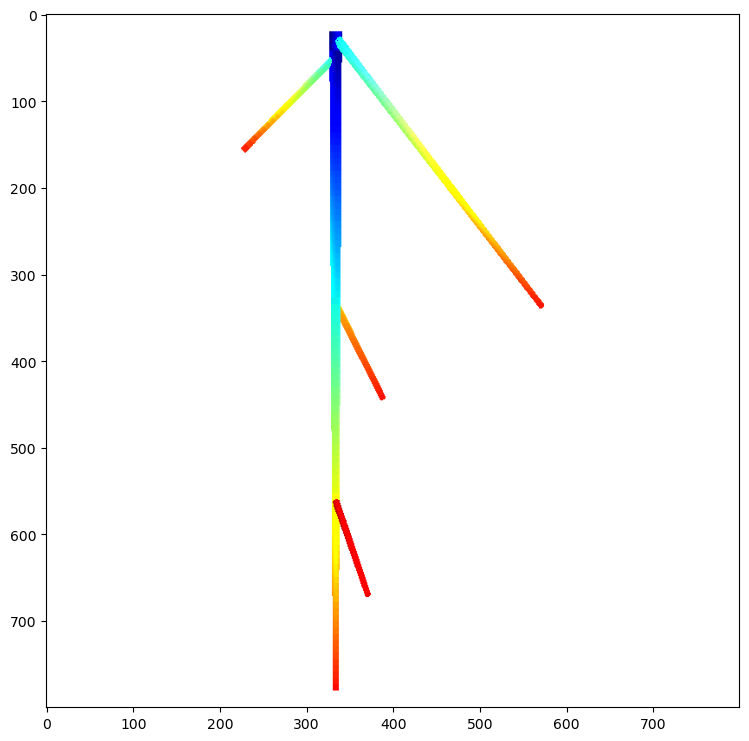

In [83]:
s = mtg_scene(g57,prop_cmap='age') 
view(s) 

* **109**

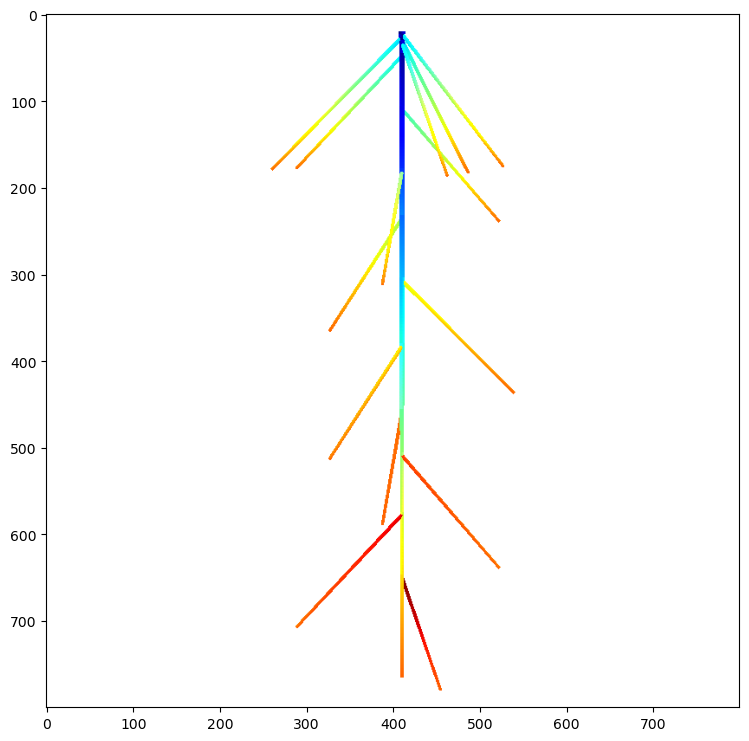

In [84]:
s = mtg_scene(g109,prop_cmap='age') 
view(s) # use PlantGL(s) to display in 3D

## Calculation of axial conductances K from the evolution laws

### Define laws for the different root types

In [85]:
# Laws are defined with respect to relative position, so experimental laws are slightly modified
sr_law = lambda x: 2135.05* (x * 29.5) + 21338.63 # x is replace by r * xmax where r is the relative position
cr_law = lambda x: 9228.45* (x *17.4) + 42600.14
lr_law = lambda x: 2951.65* (x * 13.6) + 2720.09

In [86]:
from openalea.hydroroot.millet import conductance as conductance_millet; reload(conductance)

<module 'openalea.hydroroot.conductance' from 'C:\\Users\\ADAMANDOUR\\OneDrive - CIMMYT\\Documents\\Code\\Python\\hydroroot\\src\\openalea\\hydroroot\\conductance.py'>

### Compute K for the lines

* **57**

In [87]:
g57 = conductance_millet.compute_K_from_laws(g57, sr_law, cr_law, lr_law)

* **109**

In [88]:
g109 = conductance_millet.compute_K_from_laws(g109, sr_law, cr_law, lr_law)

 ## Compute surface and volume for the lines

In [94]:
from openalea.hydroroot import radius

* **57**

In [95]:
g57, surface57 = radius.compute_surface(g57)
g57, volume57 = radius.compute_volume(g57)

In [96]:
print( 'surface (sq. meters): ',surface57)
print ('volume (cube meters): ',volume57)

surface (sq. meters):  9.497065092701509e-06
volume (cube meters):  3.297623262612453e-10


* **109**

In [97]:
g109, surface109 = radius.compute_surface(g109)
g109, volume109 = radius.compute_volume(g109)

In [98]:
print( 'surface (sq. meters): ',surface109)
print ('volume (cube meters): ',volume109)

surface (sq. meters):  3.634075428164427e-05
volume (cube meters):  1.1328779032705608e-09


## Compute the radial conductances

In [99]:
from openalea.hydroroot.length import fit_law
from openalea.hydroroot import conductance

### Define data with respect to the relative position

In [100]:
radial_conductivity_data57 =  ([0,1], [300., 300.])
radial_conductivity_data109 =  ([0,1], [300., 300.])

### Radial law

In [101]:
def radial_law(radial_data):
    xr, yr = radial_data
    radial_conductivity_law = fit_law(xr, yr)
    return radial_conductivity_law

In [102]:
radial_law57 = radial_law(radial_conductivity_data57)
radial_law109 = radial_law(radial_conductivity_data109)

### compute radial conducances

In [103]:
g57 = conductance_millet.fit_property_from_spline(g57, radial_law57, 'relative_position', 'k0')
g57 = conductance.compute_k(g57, k0='k0')

In [104]:
g109 = conductance_millet.fit_property_from_spline(g109, radial_law109, 'relative_position', 'k0')
g109 = conductance.compute_k(g109, k0='k0')

## Use HydroRoot model to compute Water flux

In [107]:
from openalea.hydroroot import flux

### Define hydraulic params

In [108]:
# parameters
Jv = 0.1
psi_e = 0.4
psi_base = 0.1

### Computation of flux in millet root system

In [109]:
#57
g57 = flux.flux(g57, Jv, psi_e, psi_base, invert_model=True)

In [110]:
#109
g109 = flux.flux(g109, Jv, psi_e, psi_base, invert_model=True)

### Visualizing water fluxes for two architecturally contrasted millet lines

In [135]:
s57 = mtg_scene(g57,prop_cmap='j')
#s109 = mtg_scene(g109,prop_cmap='j') 
PlantGL(s57)
#PlantGL(s109)

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

### Calculate global water at the root base

In [122]:
from openalea import plantgl as pgl # 2D view
from openalea.widgets import plantgl as wgl

In [126]:
def compute_Jv_global(g, HAS_SOIL=False):
    Keqs = g.property('Keq')
    v_base = next(g.component_roots_at_scale_iter(g.root, scale=1))
    Keq = Keqs[v_base]
    
    if HAS_SOIL:
        psi_e_base = g.property('psi_e')[v_base]
    else:
        psi_e_base = psi_e
    Jv_global = Keq * (psi_e_base - psi_base)
    return Jv_global

* **57**

In [127]:
J57 = compute_Jv_global(g57)
print(f'Global water flux (microL/s): {J57}')

Global water flux (microL/s): 0.0008547352629919072


* **109** 

In [128]:
J109 = compute_Jv_global(g109)
print(f'Global water flux (microL/s): {J109}')

Global water flux (microL/s): 0.0032706488579380003


In [136]:
from openalea.hydroroot.display import property_scale_bar